# **The 6-step Data Quality Method**
## https://github.com/royruddle/6-step-data-quality-method

This is the notebook that is used in the YouTube video about **Step 6** of the method (https://www.youtube.com/watch?v=XYL80v2_vjc), and shows how to use the vizdataquality package to investigate data quality.

The 6 steps are:
1. Is anything obviously wrong?
2. Watch out for special values
3. Is any data missing?
4. Check each variable
5. Check combinations of variables
6. Profile the cleaned data

## **Step 6: Profile the cleaned data**

This step uses off-street parking fines data ('Quarter 4 201819.csv'; https://datamillnorth.org/dataset/v8ggw/off-street-parking-fines), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence (https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/).

## Includes: vizdataquality and other libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from vizdataquality import calculate as vdqc, plot as vdqp

## Read the fines issued information from the datafile

In [2]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Quarter 4 201819.csv')

# Only read the columns about fines issued
columns = ['PCN', 'ISSUED', 'LOCATION', 'CONTRAVENTION', 'FINE']

# Read the dataset, but only treat empty cells as missing values
df = pd.read_csv(input_filename, usecols=columns, na_values='', keep_default_na=False,
                 parse_dates=['ISSUED'], dayfirst=True, encoding='ascii', low_memory=False)

# Perform cleaning that was done in Step 4
#   - Strip leading/trailing spaces in LOCATION and CONTRAVENTION values
df['LOCATION'] = df['LOCATION'].apply(lambda x: x.strip())
df['CONTRAVENTION'] = df['CONTRAVENTION'].apply(lambda x: x.strip())

## Profile fines issued in this quarter (Jan - Mar 2019)

In [3]:
df_2019 = df[df['ISSUED'] >= pd.to_datetime('2019-01-01', yearfirst=True)].drop_duplicates()

### Uniqueness

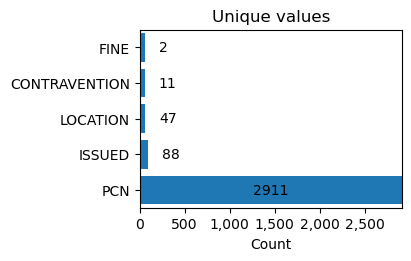

In [4]:
column_stats = vdqc.calc(df_2019, {'Unique values': True})

fig_kw = {'size_inches': (4, 2.5), 'constrained_layout': True}
num_rows = len(df_2019)
ax_kw = {'title': 'Unique values', 'xlim': (0, num_rows), 'xlabel': 'Count', 'ylabel': None}
vdqp.scalar_bar(column_stats['Number of unique values'], perceptual_threshold=0.02, vert=False,
                datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

### FINE

In [5]:
print('Total of fines issued =', '£' + str(df_2019['FINE'].sum()))

Total of fines issued = £148510


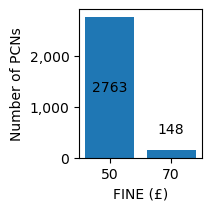

In [6]:
# Plot the number of fines of each value
vc_fine = df_2019['FINE'].value_counts()
fig_kw = {'size_inches': (2, 2), 'constrained_layout': True}
ax_kw = {'xlabel': 'FINE (£)', 'ylim': (0, vc_fine.sum()), 'ylabel': 'Number of PCNs'}
vdqp.scalar_bar(vc_fine.sort_index(), datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

### Date ISSUED

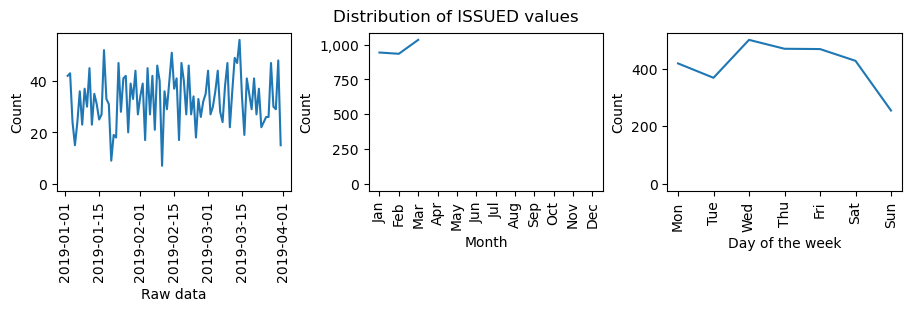

In [7]:
fig_kw = {'size_inches': (9, 3), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of ISSUED values'}
components = ['raw data', 'month', 'dayofweek']
xrot = [90, 90, 90]
vdqp.plotgrid('datetime distribution', df_2019['ISSUED'], num_rows=1, xlabels_rotate=xrot,
              fig_kw=fig_kw, ax_kw=ax_kw, components=components)

### CONTRAVENTION

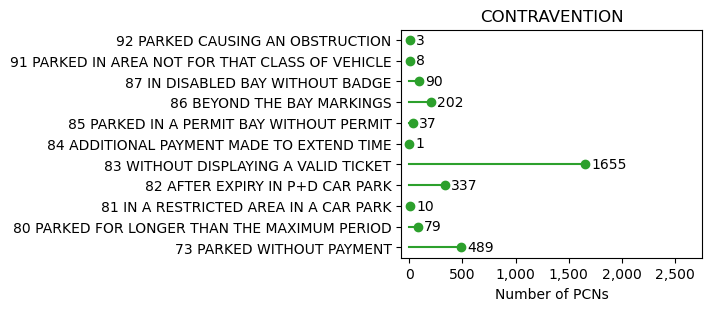

In [8]:
fig_kw = {'size_inches': (7, 3), 'constrained_layout': True}
ax_kw = {'title': 'CONTRAVENTION', 'xlabel': 'Number of PCNs', 'xlim': (-75, 2750), 'ylabel': None}
vdqp.lollipop(df_2019['CONTRAVENTION'].value_counts(), vert=False, datalabels=True,
              fig_kw=fig_kw, ax_kw=ax_kw)

#### FINE for each CONTRAVENTION

In [9]:
columns = ['CONTRAVENTION', 'FINE']
print(df_2019[columns].drop_duplicates().sort_values('CONTRAVENTION').to_string(index=False))

                                  CONTRAVENTION  FINE
                      73 PARKED WITHOUT PAYMENT    50
   80 PARKED FOR LONGER THAN THE MAXIMUM PERIOD    50
          81 IN A RESTRICTED AREA IN A CAR PARK    70
                82 AFTER EXPIRY IN P+D CAR PARK    50
           83 WITHOUT DISPLAYING A VALID TICKET    50
      84 ADDITIONAL PAYMENT MADE TO EXTEND TIME    50
       85 PARKED IN A PERMIT BAY WITHOUT PERMIT    70
                     86 BEYOND THE BAY MARKINGS    50
               87 IN DISABLED BAY WITHOUT BADGE    70
91 PARKED IN AREA NOT FOR THAT CLASS OF VEHICLE    70
               92 PARKED CAUSING AN OBSTRUCTION    70


### LOCATION

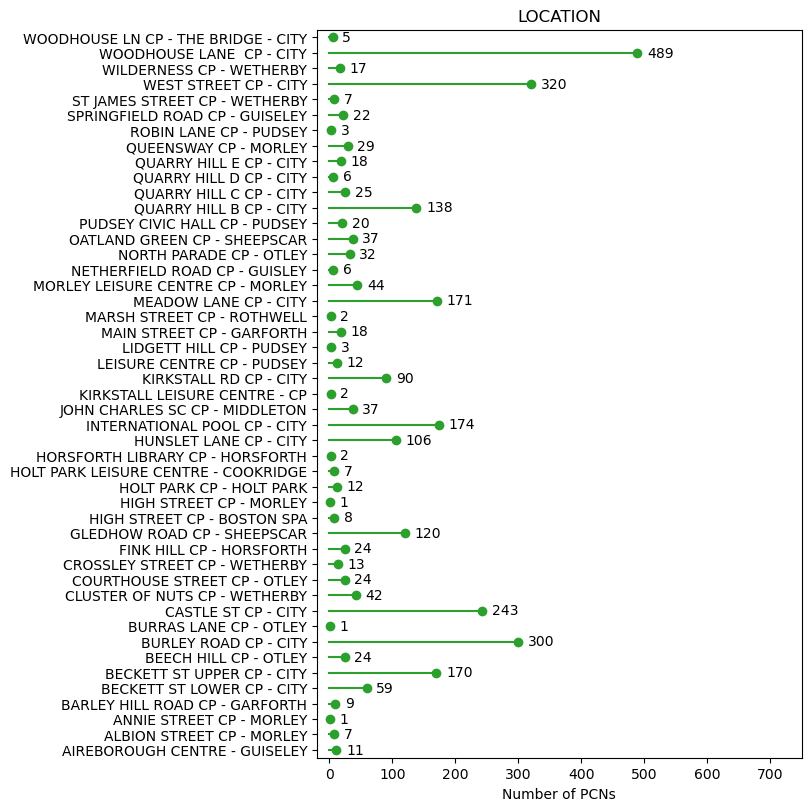

In [10]:
fig_kw = {'size_inches': (8, 8), 'constrained_layout': True}
ax_kw = {'title': 'LOCATION', 'xlabel': 'Number of PCNs', 'xlim': (-20, 750), 'ylabel': None}
vdqp.lollipop(df_2019['LOCATION'].value_counts(), vert=False, datalabels=True,
              fig_kw=fig_kw, ax_kw=ax_kw)